# Ensemble Methods untuk Klasifikasi

Notebook ini membahas beberapa **metode ensemble** untuk tugas klasifikasi dengan alur dari konsep paling sederhana sampai yang lebih kompleks.

Ide utama ensemble adalah **menggabungkan beberapa model** agar hasil prediksi menjadi lebih stabil, lebih akurat, atau lebih tahan terhadap noise dibanding satu model tunggal.

Fokus notebook ini adalah **klasifikasi biner** agar konsep ensemble lebih mudah dipahami.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

## 2. Membuat dataset 2 dimensi untuk visualisasi

Sebelum memakai dataset nyata, kita mulai dari dataset sintetis `make_moons`.

Alasannya:

- dataset ini hanya punya **dua fitur**, sehingga decision boundary mudah digambar,
- pola kelasnya **non-linear**, sehingga perbedaan antar metode ensemble lebih mudah terlihat.

Setelah data dibuat, kita langsung membaginya menjadi data training dan data testing.

In [3]:
X_2d, y_2d = make_moons(
    n_samples=500,
    noise=0.28,
    random_state=RANDOM_STATE
)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_2d
)

df_2d = pd.DataFrame(X_2d, columns=["fitur_1", "fitur_2"])
df_2d["kelas"] = y_2d

print("Ukuran dataset:", X_2d.shape)
print("Jumlah data training:", X_train_2d.shape[0])
print("Jumlah data testing :", X_test_2d.shape[0])
print("\nDistribusi kelas:")
print(df_2d["kelas"].value_counts().sort_index())

df_2d.head()

Ukuran dataset: (500, 2)
Jumlah data training: 375
Jumlah data testing : 125

Distribusi kelas:
kelas
0    250
1    250
Name: count, dtype: int64


,fitur_1,fitur_2,kelas
0,0.831003,-0.273867,1
1,1.146393,0.912110,0
2,1.152667,-0.458489,1
3,-0.047104,1.075660,0
4,0.465521,1.473245,0


## 3. Visualisasi dataset awal

Plot berikut membantu kita melihat bentuk dasar data.

Karena kelas saling melengkung, model linear sederhana biasanya tidak cukup baik. Di sinilah model berbasis pohon dan ensemble sering memberi keuntungan.

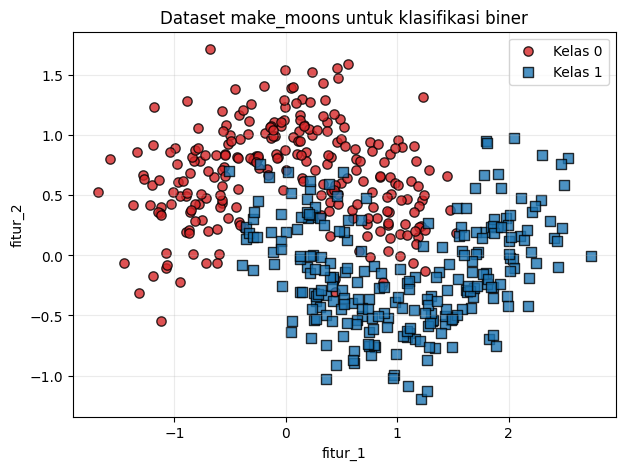

In [4]:
plt.figure(figsize=(7, 5))
for label, color, marker in [(0, "#d62728", "o"), (1, "#1f77b4", "s")]:
    mask = y_2d == label
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=color,
        marker=marker,
        s=45,
        edgecolor="black",
        alpha=0.8,
        label=f"Kelas {label}"
    )

plt.xlabel("fitur_1")
plt.ylabel("fitur_2")
plt.title("Dataset make_moons untuk klasifikasi biner")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 4. Fungsi bantu untuk evaluasi dan decision region

Agar tidak menulis kode yang sama berulang kali, kita buat dua fungsi bantu:

1. `evaluate_classifier()` untuk melatih model dan menghitung metrik evaluasi.
2. `plot_decision_region()` untuk menggambar wilayah prediksi model di bidang 2D.

Fungsi ini akan dipakai berulang untuk semua model pada bagian berikutnya.

In [5]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Melatih model lalu mengembalikan metrik evaluasi utama."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }


def plot_decision_region(ax, model, X, y, title):
    """Menggambar decision region untuk model klasifikasi biner 2D."""
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.25)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1)

    for label, color, marker in [(0, "#d62728", "o"), (1, "#1f77b4", "s")]:
        mask = y == label
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            c=color,
            marker=marker,
            s=35,
            edgecolor="black",
            alpha=0.8,
            label=f"Kelas {label}"
        )

    ax.set_title(title)
    ax.set_xlabel("fitur_1")
    ax.set_ylabel("fitur_2")
    ax.grid(alpha=0.2)

## 5. Baseline: satu decision tree

Sebelum masuk ke ensemble, kita butuh pembanding dasar.

Kita mulai dengan **satu** `DecisionTreeClassifier`. Model ini penting karena:

- banyak metode ensemble dibangun dari pohon keputusan,
- pohon tunggal sering mudah dipahami tetapi bisa **overfit**.

In [6]:
tree_2d = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
result_tree = evaluate_classifier(
    tree_2d,
    X_train_2d,
    X_test_2d,
    y_train_2d,
    y_test_2d,
    model_name="Decision Tree"
)

pd.DataFrame([result_tree])

,model,accuracy,f1_score
0,Decision Tree,0.872,0.875


## 6. Visualisasi decision region decision tree

Plot ini menunjukkan bagaimana satu pohon keputusan membagi ruang fitur.

Perhatikan bahwa batas keputusan pohon biasanya berbentuk **potongan horizontal dan vertikal**, karena keputusan pohon dibuat melalui aturan split pada satu fitur tertentu.

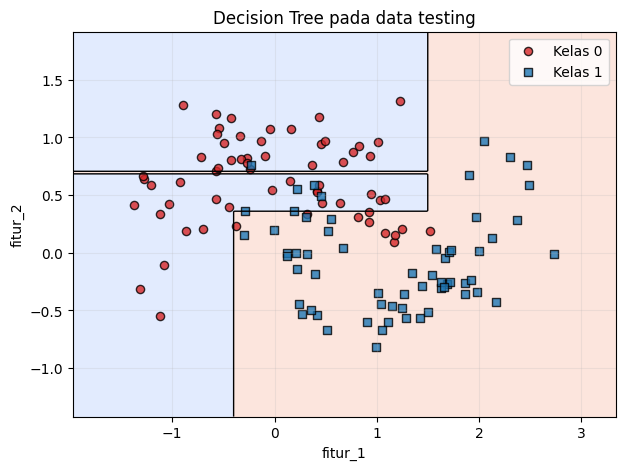

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_region(ax, tree_2d, X_test_2d, y_test_2d, "Decision Tree pada data testing")
ax.legend()
plt.show()

## 7. Bagging: banyak pohon, voting rata-rata

`BaggingClassifier` bekerja dengan ide berikut:

1. Ambil beberapa sampel bootstrap dari data training.
2. Latih satu model dasar untuk setiap sampel.
3. Gabungkan hasil prediksi seluruh model.

Untuk klasifikasi, prediksi akhir umumnya diambil dari **voting mayoritas**.

Di bawah ini kita memakai decision tree sebagai model dasar bagging.

In [8]:
bagging_2d = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE
)

result_bagging = evaluate_classifier(
    bagging_2d,
    X_train_2d,
    X_test_2d,
    y_train_2d,
    y_test_2d,
    model_name="Bagging"
)

pd.DataFrame([result_bagging])

,model,accuracy,f1_score
0,Bagging,0.888,0.887097


## 8. Membandingkan decision tree tunggal vs bagging

Visualisasi ini penting karena memperlihatkan salah satu manfaat utama bagging:

- prediksi menjadi lebih **halus**,
- model menjadi lebih **stabil**,
- variasi ekstrem dari satu pohon tunggal dapat berkurang.

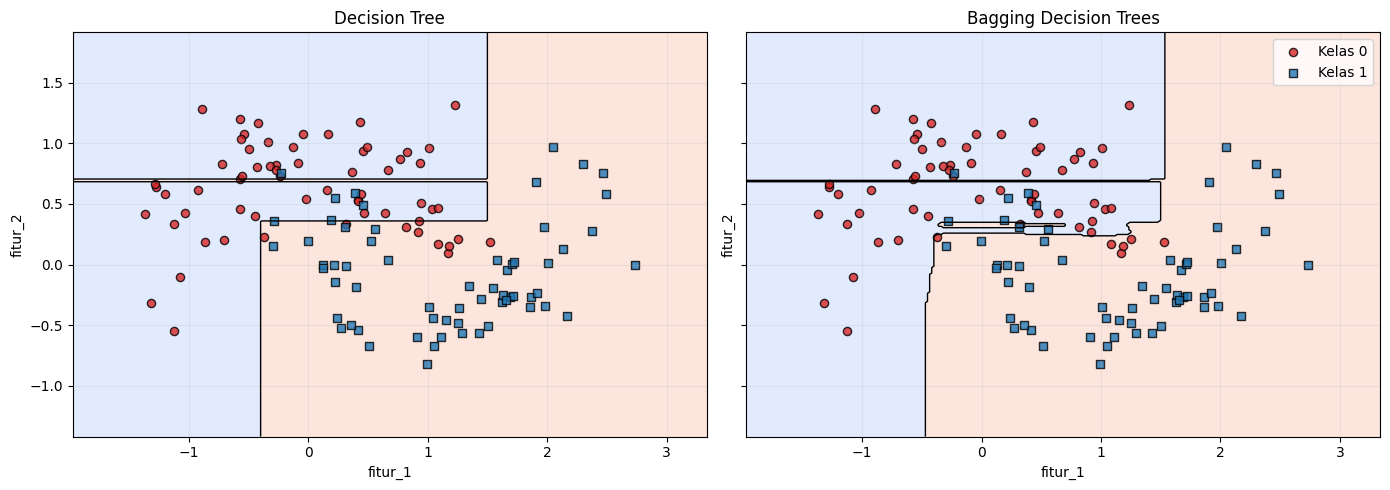

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_decision_region(axes[0], tree_2d, X_test_2d, y_test_2d, "Decision Tree")
plot_decision_region(axes[1], bagging_2d, X_test_2d, y_test_2d, "Bagging Decision Trees")

axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 9. Random forest: bagging + pemilihan fitur acak

`RandomForestClassifier` pada dasarnya adalah bagging dari banyak decision tree, tetapi dengan tambahan penting:

- setiap split pohon tidak melihat semua fitur,
- melainkan hanya sebagian fitur yang dipilih secara acak.

Akibatnya, antar pohon menjadi lebih beragam, dan ensemble biasanya bekerja lebih baik dibanding sekadar banyak pohon yang terlalu mirip.

In [10]:
random_forest_2d = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    n_jobs=1,
    random_state=RANDOM_STATE
)

result_rf = evaluate_classifier(
    random_forest_2d,
    X_train_2d,
    X_test_2d,
    y_train_2d,
    y_test_2d,
    model_name="Random Forest"
)

pd.DataFrame([result_rf])

,model,accuracy,f1_score
0,Random Forest,0.88,0.88


## 10. Visualisasi random forest dan feature importance sederhana

Kode berikut membuat dua hal:

1. decision region random forest,
2. importance dari dua fitur pada dataset 2D.

Karena dataset ini hanya punya dua fitur, feature importance-nya sederhana, tetapi konsepnya sama seperti pada dataset nyata yang lebih besar.

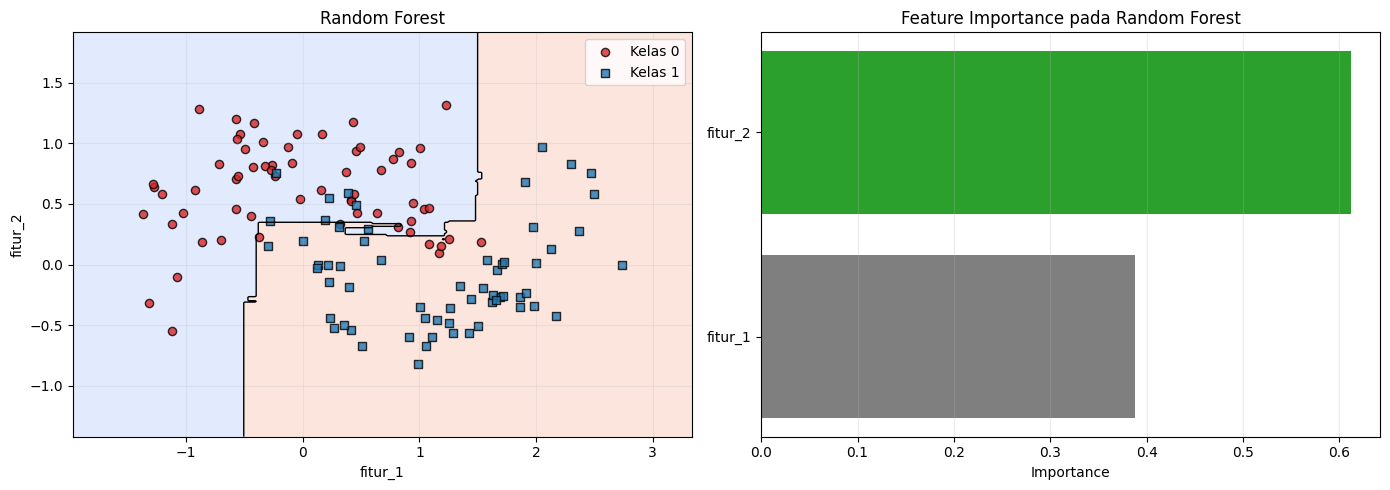

,fitur,importance
0,fitur_1,0.388312
1,fitur_2,0.611688


In [11]:
importance_2d = pd.DataFrame({
    "fitur": ["fitur_1", "fitur_2"],
    "importance": random_forest_2d.feature_importances_
}).sort_values(by="importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_region(axes[0], random_forest_2d, X_test_2d, y_test_2d, "Random Forest")
axes[0].legend(loc="upper right")

axes[1].barh(importance_2d["fitur"], importance_2d["importance"], color=["#7f7f7f", "#2ca02c"])
axes[1].set_title("Feature Importance pada Random Forest")
axes[1].set_xlabel("Importance")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

importance_2d

## 11. AdaBoost: model belajar secara berurutan

Berbeda dari bagging dan random forest yang melatih banyak model secara relatif independen, `AdaBoostClassifier` bekerja **bertahap**.

Gagasannya:

- model awal dilatih terlebih dahulu,
- data yang salah diprediksi diberi perhatian lebih besar,
- model berikutnya fokus memperbaiki kesalahan sebelumnya.

Karena itu, boosting sering dianggap lebih kompleks daripada voting atau bagging.

In [12]:
adaboost_2d = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.8,
    random_state=RANDOM_STATE
)

result_adaboost = evaluate_classifier(
    adaboost_2d,
    X_train_2d,
    X_test_2d,
    y_train_2d,
    y_test_2d,
    model_name="AdaBoost"
)

pd.DataFrame([result_adaboost])

,model,accuracy,f1_score
0,AdaBoost,0.92,0.921875


## 12. Perbandingan metrik pada dataset 2D

Sekarang kita kumpulkan semua hasil evaluasi dalam satu tabel dan satu plot.

Tujuannya adalah melihat apakah ensemble benar-benar memberi perbaikan dibanding baseline decision tree tunggal.

In [13]:
results_2d = pd.DataFrame([
    result_tree,
    result_bagging,
    result_rf,
    result_adaboost
]).sort_values(by="f1_score", ascending=False)

results_2d

,model,accuracy,f1_score
3,AdaBoost,0.920,0.921875
1,Bagging,0.888,0.887097
2,Random Forest,0.880,0.880000
0,Decision Tree,0.872,0.875000


## 13. Plot perbandingan metrik pada dataset 2D

Dengan bar chart, kita bisa lebih cepat melihat model mana yang memberikan skor `accuracy` dan `F1-score` terbaik.

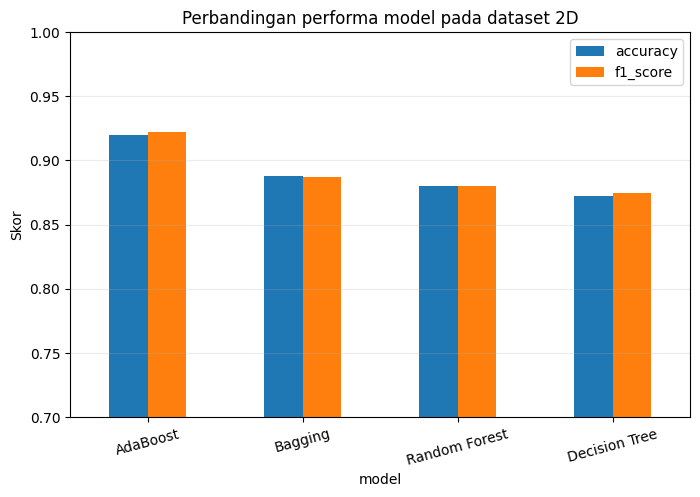

In [14]:
plot_df_2d = results_2d.set_index("model")[["accuracy", "f1_score"]]

ax = plot_df_2d.plot(kind="bar", figsize=(8, 5), rot=15)
ax.set_title("Perbandingan performa model pada dataset 2D")
ax.set_ylabel("Skor")
ax.set_ylim(0.7, 1.0)
ax.grid(axis="y", alpha=0.25)
plt.show()

## 14. Visualisasi seluruh decision region sekaligus

Plot grid berikut penting karena menampilkan seluruh model pada ruang fitur yang sama.

Dengan melihat keempat plot berdampingan, kita bisa memahami perbedaan karakter:

- decision tree: paling tajam dan mudah overfit,
- bagging: lebih stabil,
- random forest: stabil dengan variasi antar pohon,
- AdaBoost: adaptif terhadap kesalahan sebelumnya.

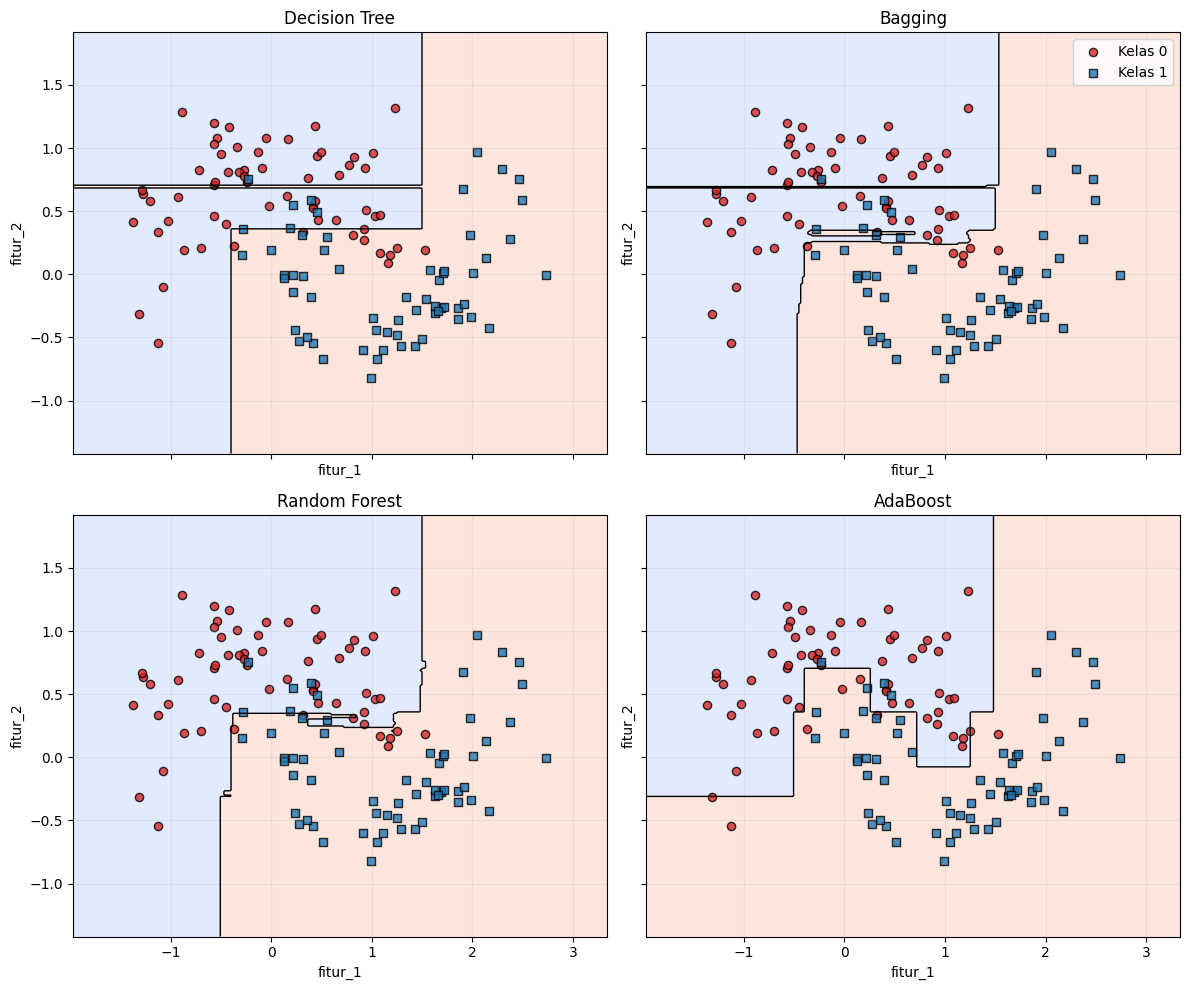

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

plot_decision_region(axes[0, 0], tree_2d, X_test_2d, y_test_2d, "Decision Tree")
plot_decision_region(axes[0, 1], bagging_2d, X_test_2d, y_test_2d, "Bagging")
plot_decision_region(axes[1, 0], random_forest_2d, X_test_2d, y_test_2d, "Random Forest")
plot_decision_region(axes[1, 1], adaboost_2d, X_test_2d, y_test_2d, "AdaBoost")

axes[0, 1].legend(loc="upper right")
plt.tight_layout()
plt.show()

# Bagian B — Ensemble pada Dataset Nyata

Setelah melihat perilaku model pada data 2D, sekarang kita beralih ke dataset nyata.

Tujuannya adalah melihat bagaimana ensemble dipakai dalam alur klasifikasi yang lebih praktis.

## 15. Memuat dataset Breast Cancer Wisconsin

Dataset ini adalah klasifikasi biner yang sangat populer di scikit-learn.

Kita akan memakai dataset ini untuk:

- membandingkan model tunggal dan ensemble,
- membuat `VotingClassifier`,
- melihat `feature importance` dari random forest.

In [16]:
breast_cancer = load_breast_cancer(as_frame=True)
X_real = breast_cancer["data"]
y_real = breast_cancer["target"]
label_names = [str(name) for name in breast_cancer["target_names"]]
label_map = dict(enumerate(label_names))

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_real
)

print("Ukuran dataset:", X_real.shape)
print("Nama kelas:", label_names)
print("\nDistribusi kelas:")
print(y_real.value_counts().rename(index=label_map))

X_real.head()

Ukuran dataset: (569, 30)
Nama kelas: ['malignant', 'benign']

Distribusi kelas:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 16. Menyiapkan model tunggal dan `VotingClassifier`

Untuk voting ensemble, kita sengaja menggabungkan model yang karakternya berbeda:

- `GaussianNB` mewakili model probabilistik sederhana,
- `KNeighborsClassifier` mewakili model berbasis kedekatan,
- `DecisionTreeClassifier` mewakili model berbasis aturan,
- `VotingClassifier` menggabungkan ketiganya dengan **soft voting**.

Selain itu kita tambahkan `RandomForestClassifier` sebagai ensemble pembanding lain.

In [17]:
models_real = {
    "Gaussian Naive Bayes": GaussianNB(),
    "K-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=11))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Soft Voting": VotingClassifier(
        estimators=[
            ("gnb", GaussianNB()),
            ("knn", Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(n_neighbors=11))
            ])),
            ("tree", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))
        ],
        voting="soft"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        n_jobs=1,
        random_state=RANDOM_STATE
    )
}

results_real = []
fitted_models_real = {}

for name, model in models_real.items():
    model.fit(X_train_real, y_train_real)
    y_pred = model.predict(X_test_real)

    results_real.append({
        "model": name,
        "accuracy": accuracy_score(y_test_real, y_pred),
        "f1_score": f1_score(y_test_real, y_pred)
    })

    fitted_models_real[name] = model

df_results_real = pd.DataFrame(results_real).sort_values(by="f1_score", ascending=False)
df_results_real

,model,accuracy,f1_score
1,K-NN,0.973684,0.979592
3,Soft Voting,0.956140,0.965986
4,Random Forest,0.956140,0.965517
0,Gaussian Naive Bayes,0.938596,0.951724
2,Decision Tree,0.938596,0.951049


## 17. Visualisasi perbandingan performa pada dataset nyata

Pada bagian ini kita melihat apakah voting ensemble dan random forest memberi keuntungan dibanding model tunggal.

Bar chart membantu kita membandingkan hasil secara cepat tanpa harus membaca tabel satu per satu.

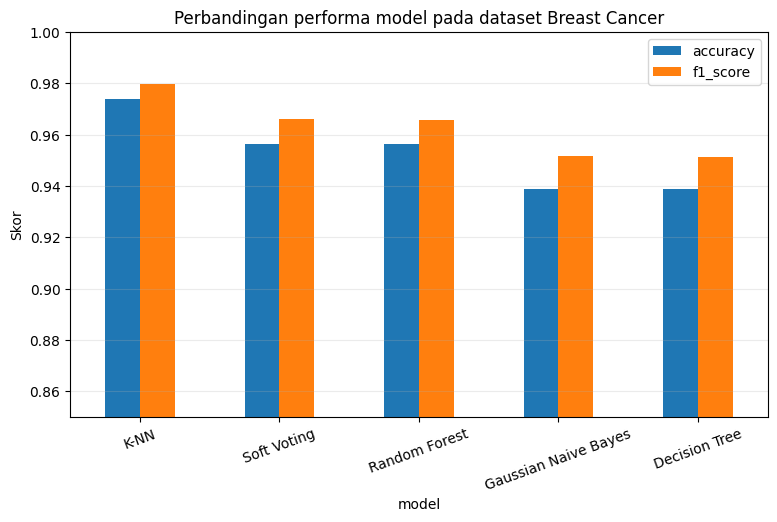

In [18]:
plot_df_real = df_results_real.set_index("model")[["accuracy", "f1_score"]]

ax = plot_df_real.plot(kind="bar", figsize=(9, 5), rot=20)
ax.set_title("Perbandingan performa model pada dataset Breast Cancer")
ax.set_ylabel("Skor")
ax.set_ylim(0.85, 1.0)
ax.grid(axis="y", alpha=0.25)
plt.show()

## 18. Confusion matrix untuk `Soft Voting`

Metrik ringkas seperti accuracy dan F1-score penting, tetapi kadang kita juga perlu melihat **jenis kesalahan** model.

Confusion matrix membantu menjawab pertanyaan:

- berapa data kelas `malignant` yang salah diprediksi sebagai `benign`,
- dan sebaliknya.

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



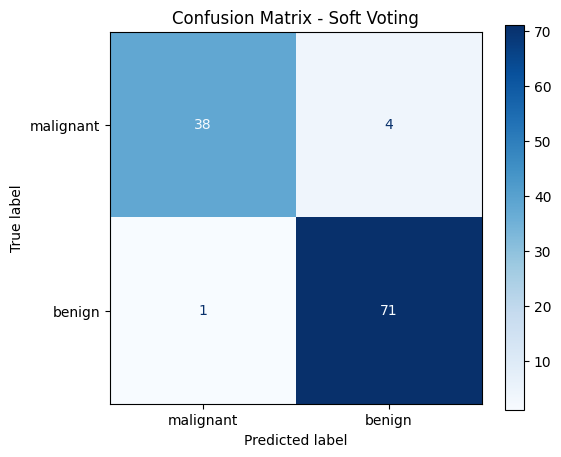

In [19]:
soft_voting_real = fitted_models_real["Soft Voting"]
y_pred_voting = soft_voting_real.predict(X_test_real)

print(classification_report(y_test_real, y_pred_voting, target_names=label_names))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_real,
    y_pred_voting,
    display_labels=label_names,
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix - Soft Voting")
plt.show()

## 19. Feature importance pada random forest

Salah satu kelebihan random forest adalah kita dapat melihat **kontribusi relatif tiap fitur**.

Plot berikut menampilkan 10 fitur paling penting menurut random forest pada dataset breast cancer.

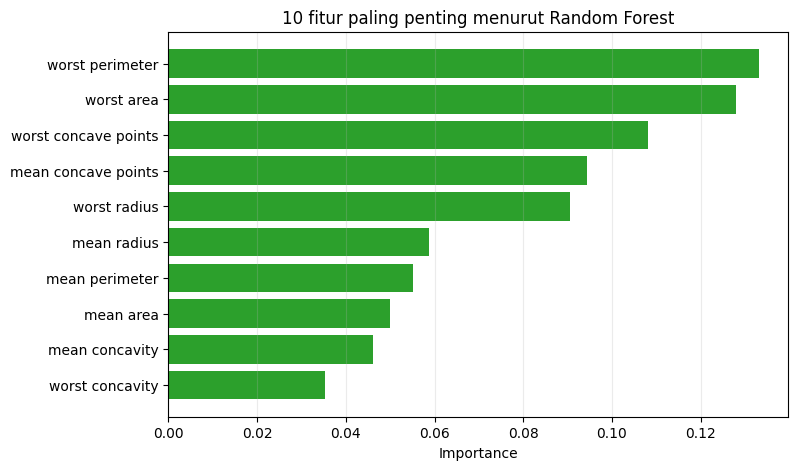

,fitur,importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


In [20]:
random_forest_real = fitted_models_real["Random Forest"]

importance_real = pd.DataFrame({
    "fitur": X_real.columns,
    "importance": random_forest_real.feature_importances_
}).sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_real["fitur"][::-1], importance_real["importance"][::-1], color="#2ca02c")
plt.xlabel("Importance")
plt.title("10 fitur paling penting menurut Random Forest")
plt.grid(axis="x", alpha=0.25)
plt.show()

importance_real

## 20. Ringkasan pembelajaran

Dari notebook ini, kita mempelajari hal-hal berikut:

1. **Decision tree tunggal** mudah dipahami, tetapi relatif lebih mudah overfit.
2. **Bagging** mengurangi variansi dengan melatih banyak model pada sampel bootstrap yang berbeda.
3. **Random forest** adalah bagging dari banyak pohon dengan tambahan pemilihan fitur acak pada tiap split.
4. **Boosting** seperti AdaBoost melatih model secara berurutan untuk memperbaiki kesalahan model sebelumnya.
5. **VotingClassifier** menggabungkan model yang berbeda dan mengambil keputusan kolektif.
6. Pada dataset nyata, ensemble sering memberi performa yang kompetitif sekaligus informasi tambahan seperti feature importance.

## Pertanyaan diskusi

1. Mengapa bagging cenderung menurunkan variansi model?
2. Apa perbedaan utama antara bagging dan boosting?
3. Mengapa random forest sering lebih baik daripada satu decision tree?
4. Kapan soft voting lebih masuk akal dibanding hard voting?
5. Apakah model dengan accuracy tertinggi selalu pilihan terbaik? Jelaskan.